In [1]:
import pandas as pd
import numpy as np
import shap
import joblib
import matplotlib.pyplot as plt

print("XAI libraries loaded successfully!")

XAI libraries loaded successfully!


In [2]:
model = joblib.load("lightgbm_model.pkl")

print("LightGBM model loaded successfully!")
print(model)

LightGBM model loaded successfully!
LGBMClassifier(random_state=42)


In [3]:
X_train = pd.read_csv("X_train.csv")
X_test = pd.read_csv("X_test.csv")

y_train = pd.read_csv("y_train.csv").squeeze()
y_test = pd.read_csv("y_test.csv").squeeze()

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

print("\nFeatures:")
print(X_test.columns.tolist())

Training data: (405756, 11)
Testing data: (101440, 11)

Features:
['URL_Length', 'No_of_Dots', 'No_of_Hyphens', 'No_of_Digits', 'Has_HTTPS', 'No_of_Slashes', 'No_of_Underscores', 'No_of_QuestionMarks', 'No_of_EqualSigns', 'No_of_At', 'Has_IP']


In [4]:
predictions = model.predict(X_test)

probabilities = model.predict_proba(X_test)[:, 1]

print("First 10 predictions:")
print(predictions[:10])

print("\nFirst 10 phishing probabilities:")
print(probabilities[:10])

c:\Users\anugr\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\anugr\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
  File "c:\Users\anugr\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\anugr\AppData\Local\Python\pythoncore-3.1

First 10 predictions:
[0 0 1 1 0 0 0 0 1 0]

First 10 phishing probabilities:
[0.13902016 0.15525695 0.98654635 0.91024768 0.18475157 0.18694517
 0.00382081 0.25759434 0.62057912 0.0214811 ]


In [5]:
explainer = shap.TreeExplainer(model)

print("SHAP TreeExplainer created successfully!")

SHAP TreeExplainer created successfully!


In [6]:
X_sample = X_test.sample(
    n=min(1000, len(X_test)),
    random_state=42
)

shap_values = explainer(X_sample)

print("SHAP values calculated!")
print(shap_values.values.shape)

SHAP values calculated!
(1000, 11)


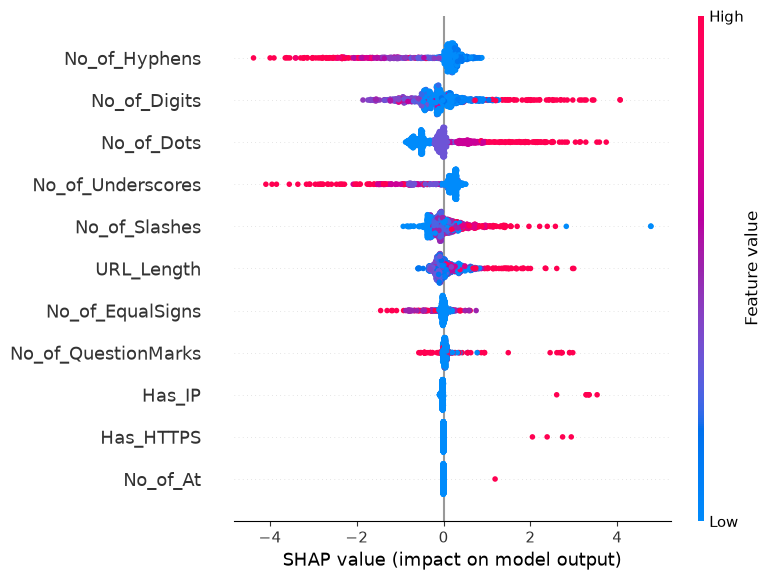

In [7]:
shap.summary_plot(
    shap_values,
    X_sample
)

In [8]:
# Find a test sample predicted as phishing
phishing_indices = np.where(model.predict(X_test) == 1)[0]

sample_index = phishing_indices[0]

sample = X_test.iloc[[sample_index]]

prediction = model.predict(sample)[0]
probability = model.predict_proba(sample)[0, 1]

print("Sample index:", sample_index)
print("Prediction:", "PHISHING" if prediction == 1 else "LEGITIMATE")
print(f"Phishing probability: {probability * 100:.2f}%")

print("\nFeature values:")
display(sample)

Sample index: 2
Prediction: PHISHING
Phishing probability: 98.65%

Feature values:


,URL_Length,No_of_Dots,No_of_Hyphens,No_of_Digits,Has_HTTPS,No_of_Slashes,No_of_Underscores,No_of_QuestionMarks,No_of_EqualSigns,No_of_At,Has_IP
2,142,14,0,39,0,2,0,0,0,0,0


In [9]:
sample_shap = explainer(sample)

print("SHAP explanation generated!")

SHAP explanation generated!


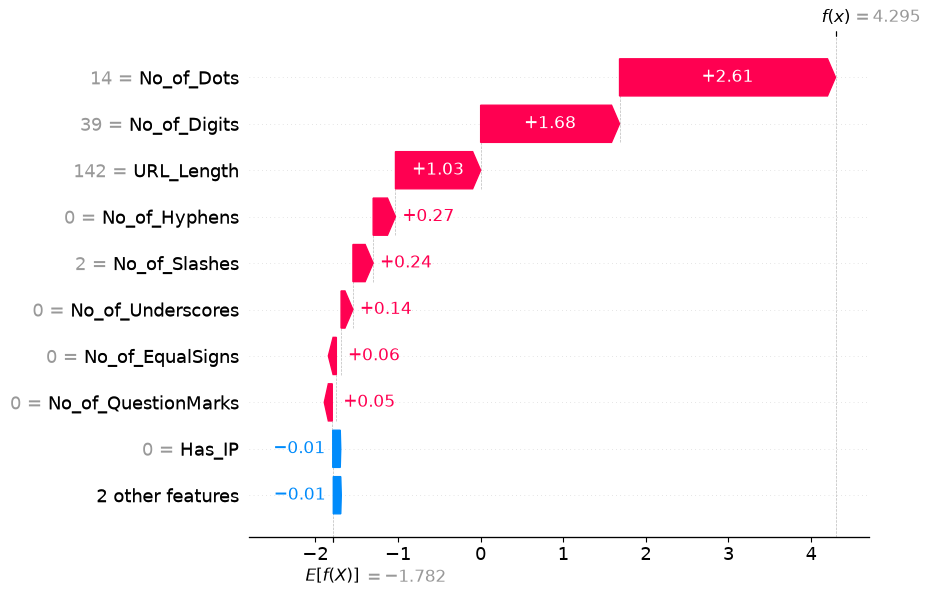

In [10]:
shap.plots.waterfall(sample_shap[0])

In [11]:
shap_data = pd.DataFrame({
    "Feature": sample.columns,
    "Value": sample.iloc[0].values,
    "SHAP_Value": sample_shap.values[0]
})

shap_data["Impact"] = shap_data["SHAP_Value"].abs()

shap_data = shap_data.sort_values(
    "Impact",
    ascending=False
)

shap_data

,Feature,Value,SHAP_Value,Impact
1,No_of_Dots,14,2.613524,2.613524
3,No_of_Digits,39,1.680704,1.680704
0,URL_Length,142,1.030741,1.030741
2,No_of_Hyphens,0,0.270014,0.270014
5,No_of_Slashes,2,0.244615,0.244615
6,No_of_Underscores,0,0.143449,0.143449
8,No_of_EqualSigns,0,0.057329,0.057329
7,No_of_QuestionMarks,0,0.049447,0.049447
10,Has_IP,0,-0.005988,0.005988
4,Has_HTTPS,0,-0.004052,0.004052
